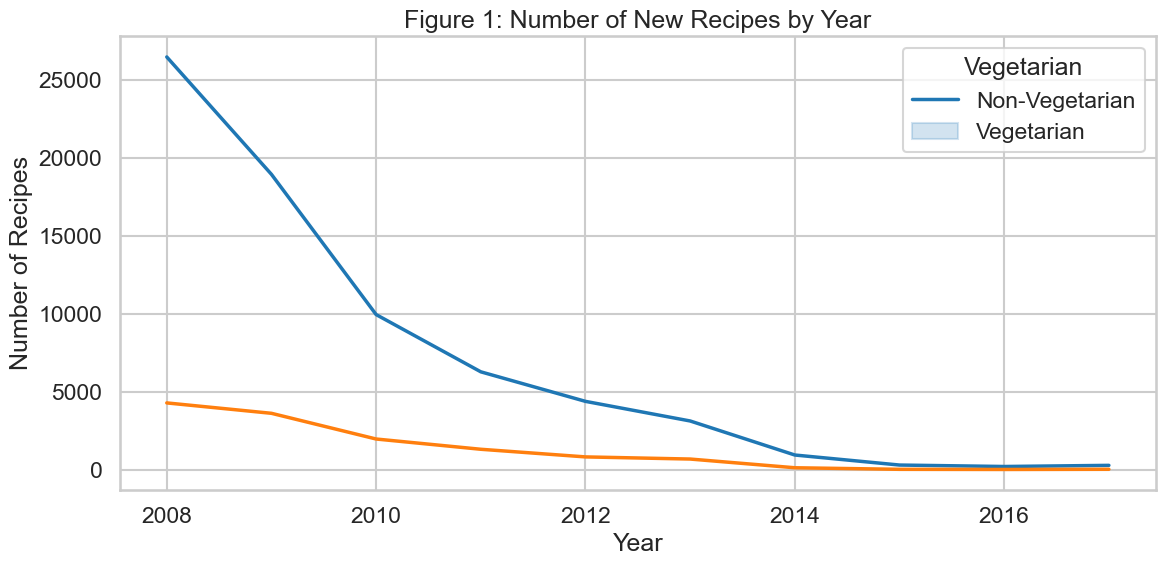

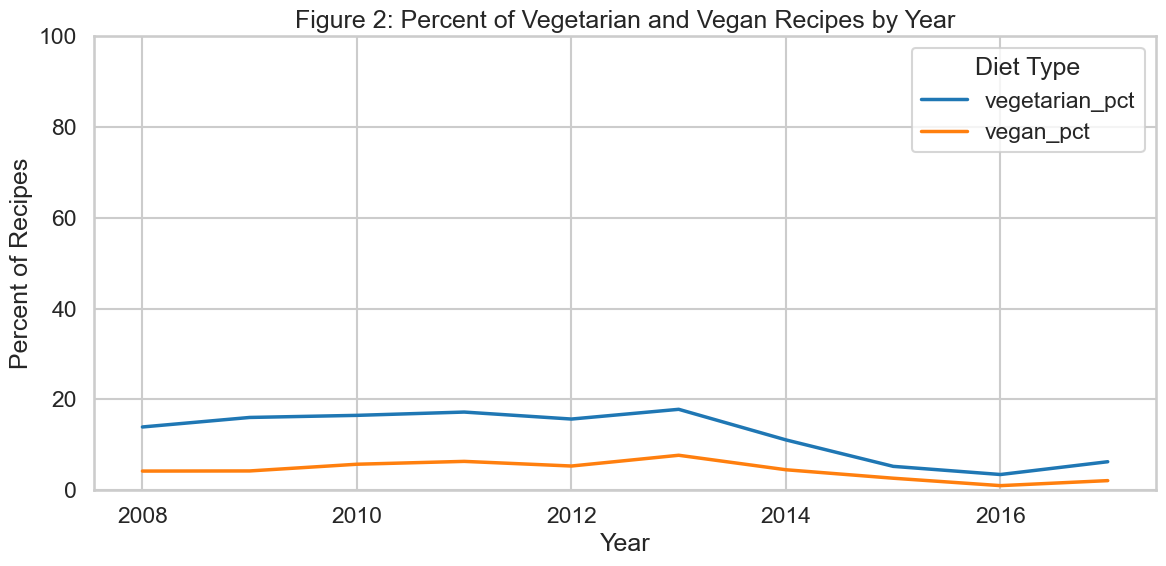

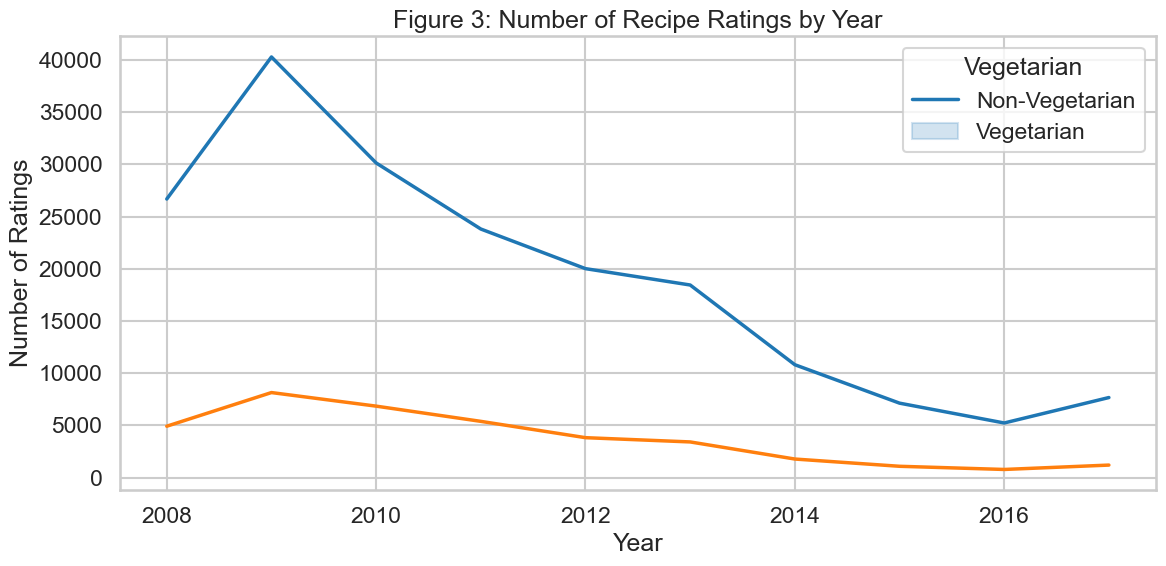

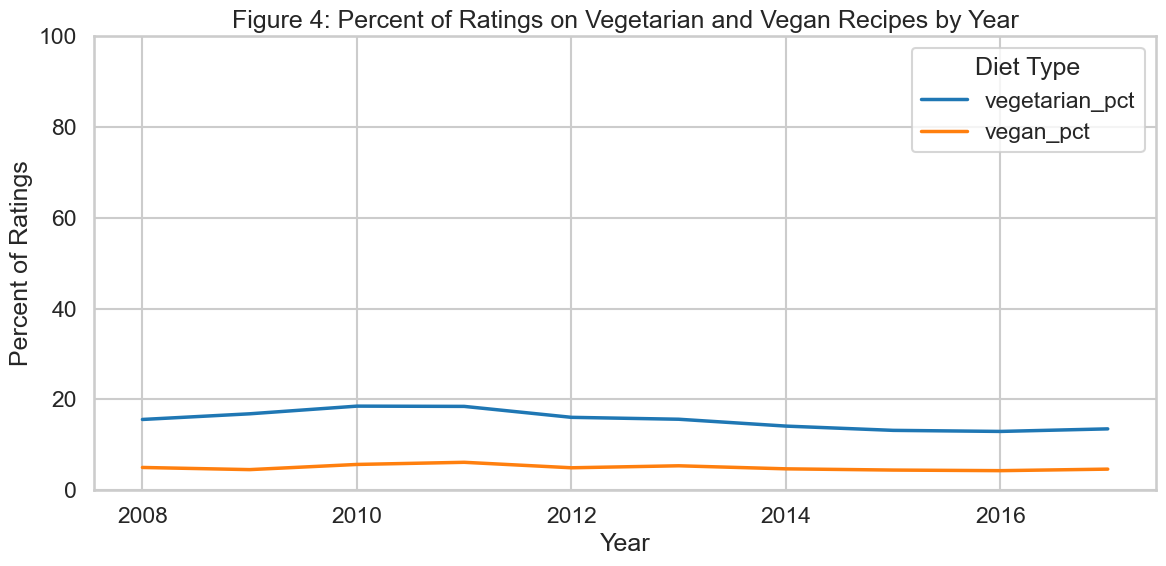

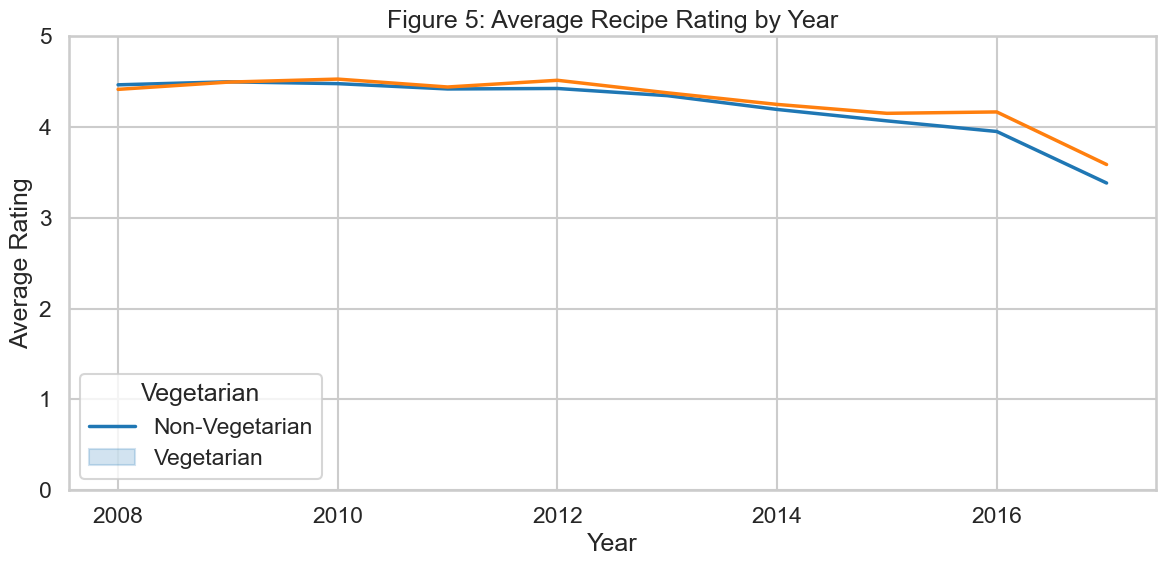

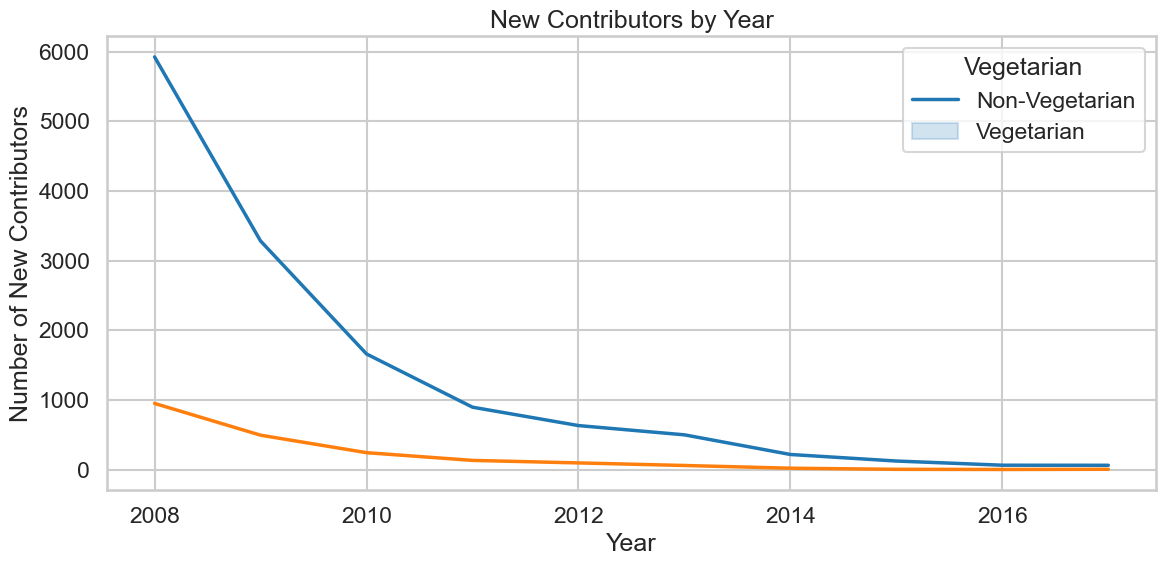

In [1]:
# Megan Pokal
# DSC680-T301 Applied Data Science (2265-1)
# Amirfarrokh Iranitalab
# April 12, 2026
# Final Project: Milestone 3

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ast import literal_eval

# Style for graphs
sns.set_style("whitegrid")
sns.set_context("talk")

# Custom colors
veg_meat = ["#454d66", "#b7e778", "#1fab89"]   # dark = non-veg, green = vegetarian, teal = vegan

# Load the datasets
recipes = pd.read_csv("../RAW_recipes.csv")
interactions = pd.read_csv("../RAW_interactions.csv")

# Cleaning the data
# Convert dates
recipes["submitted"] = pd.to_datetime(recipes["submitted"], errors="coerce")
interactions["date"] = pd.to_datetime(interactions["date"], errors="coerce")

# Filter to 2008–2017
recipes = recipes[(recipes["submitted"] >= "2008-01-01") & (recipes["submitted"] <= "2017-12-31")].copy()
interactions = interactions[(interactions["date"] >= "2008-01-01") & (interactions["date"] <= "2017-12-31")].copy()

# Remove extreme outlier in minutes
recipes = recipes[recipes["minutes"] < 1051200].copy()

# Create year columns
recipes["year"] = recipes["submitted"].dt.year
interactions["year"] = interactions["date"].dt.year

# Convert tags to lists
recipes["tags"] = recipes["tags"].apply(lambda x: literal_eval(str(x)))

# Create vegetarian / vegan flags
recipes["vegetarian"] = recipes["tags"].apply(lambda x: "vegetarian" in x)
recipes["vegan"] = recipes["tags"].apply(lambda x: "vegan" in x)

# Aggregate interaction data by recipe and year
ratings_by_recipe = interactions.groupby(["recipe_id", "year"]).agg(
    rating_cnt=("rating", "count"),
    rating_avg=("rating", "mean")
).reset_index()

# Merge recipe and interaction data
recipes_and_ratings = ratings_by_recipe.merge(
    recipes[["id", "year", "submitted", "contributor_id", "vegetarian", "vegan"]],
    left_on="recipe_id",
    right_on="id",
    how="inner"
)

# Keep only useful columns
recipes_and_ratings = recipes_and_ratings.copy()

# Figure 1: Number of New Recipes by Year

# Count new recipes by year and vegetarian status
fig1_df = recipes.groupby(["year", "vegetarian"]).agg(
    recipe_cnt=("id", "count")
).reset_index()

# Plot Figure 1
plt.figure(figsize=(12,6))
sns.lineplot(data=fig1_df, x="year", y="recipe_cnt", hue="vegetarian", linewidth=2.5)

plt.title("Figure 1: Number of New Recipes by Year")
plt.xlabel("Year")
plt.ylabel("Number of Recipes")
plt.legend(title="Vegetarian", labels=["Non-Vegetarian", "Vegetarian"])
plt.tight_layout()
plt.show()

# Figure 2: Percent of Vegetarian Recipes by Year

# Calculate yearly percentages
fig2_df = recipes.groupby("year").agg(
    total_cnt=("id", "count"),
    vegetarian_cnt=("vegetarian", "sum"),
    vegan_cnt=("vegan", "sum")
).reset_index()

fig2_df["vegetarian_pct"] = (fig2_df["vegetarian_cnt"] / fig2_df["total_cnt"]) * 100
fig2_df["vegan_pct"] = (fig2_df["vegan_cnt"] / fig2_df["total_cnt"]) * 100

# Reshape for plotting
fig2_melt = fig2_df.melt(
    id_vars="year",
    value_vars=["vegetarian_pct", "vegan_pct"],
    var_name="Diet Type",
    value_name="Percent"
)

# Plot Figure 2
plt.figure(figsize=(12,6))
sns.lineplot(data=fig2_melt, x="year", y="Percent", hue="Diet Type", linewidth=2.5)

plt.title("Figure 2: Percent of Vegetarian and Vegan Recipes by Year")
plt.xlabel("Year")
plt.ylabel("Percent of Recipes")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# Figure 3: Number of Recipe Ratings by Year

# Total ratings by year and vegetarian status
fig3_df = recipes_and_ratings.groupby(["year_x", "vegetarian"]).agg(
    rating_cnt=("rating_cnt", "sum")
).reset_index()

fig3_df = fig3_df.rename(columns={"year_x": "year"})

# Plot Figure 3
plt.figure(figsize=(12,6))
sns.lineplot(data=fig3_df, x="year", y="rating_cnt", hue="vegetarian", linewidth=2.5)

plt.title("Figure 3: Number of Recipe Ratings by Year")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")
plt.legend(title="Vegetarian", labels=["Non-Vegetarian", "Vegetarian"])
plt.tight_layout()
plt.show()

# Figure 4: Percent of Ratings on Vegetarian Recipes by Year

# Create vegetarian and vegan interaction counts
interaction_pct_df = recipes_and_ratings.copy()

interaction_pct_df["vegetarian_rating_cnt"] = np.where(
    interaction_pct_df["vegetarian"] == True,
    interaction_pct_df["rating_cnt"],
    0
)

interaction_pct_df["vegan_rating_cnt"] = np.where(
    interaction_pct_df["vegan"] == True,
    interaction_pct_df["rating_cnt"],
    0
)

# Aggregate by year
fig4_df = interaction_pct_df.groupby("year_x").agg(
    total_cnt=("rating_cnt", "sum"),
    vegetarian_cnt=("vegetarian_rating_cnt", "sum"),
    vegan_cnt=("vegan_rating_cnt", "sum")
).reset_index()

fig4_df = fig4_df.rename(columns={"year_x": "year"})

fig4_df["vegetarian_pct"] = (fig4_df["vegetarian_cnt"] / fig4_df["total_cnt"]) * 100
fig4_df["vegan_pct"] = (fig4_df["vegan_cnt"] / fig4_df["total_cnt"]) * 100

# Reshape for plotting
fig4_melt = fig4_df.melt(
    id_vars="year",
    value_vars=["vegetarian_pct", "vegan_pct"],
    var_name="Diet Type",
    value_name="Percent"
)

# Plot Figure 4
plt.figure(figsize=(12,6))
sns.lineplot(data=fig4_melt, x="year", y="Percent", hue="Diet Type", linewidth=2.5)

plt.title("Figure 4: Percent of Ratings on Vegetarian and Vegan Recipes by Year")
plt.xlabel("Year")
plt.ylabel("Percent of Ratings")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# Figure 5: Average Recipe Rating by Year

# Average ratings by year and vegetarian status
fig5_df = recipes_and_ratings.groupby(["year_x", "vegetarian"]).agg(
    rating_avg=("rating_avg", "mean")
).reset_index()

fig5_df = fig5_df.rename(columns={"year_x": "year"})

# Plot Figure 5
plt.figure(figsize=(12,6))
sns.lineplot(data=fig5_df, x="year", y="rating_avg", hue="vegetarian", linewidth=2.5)

plt.title("Figure 5: Average Recipe Rating by Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.legend(title="Vegetarian", labels=["Non-Vegetarian", "Vegetarian"])
plt.tight_layout()
plt.show()

# Figure 6: Contributor Cohort / New Contributors
# New Contributors by Year

# First recipe year per contributor
contributor_first = recipes.groupby("contributor_id").agg(
    first_year=("year", "min"),
    vegetarian_share=("vegetarian", "mean")
).reset_index()

# Label contributor as vegetarian if >50% of recipes are vegetarian
contributor_first["vegetarian"] = contributor_first["vegetarian_share"] >= 0.5

# Count contributors by first year
bonus_df = contributor_first.groupby(["first_year", "vegetarian"]).agg(
    contributor_cnt=("contributor_id", "count")
).reset_index()

# Plot New Contributors
plt.figure(figsize=(12,6))
sns.lineplot(data=bonus_df, x="first_year", y="contributor_cnt", hue="vegetarian", linewidth=2.5)

plt.title("New Contributors by Year")
plt.xlabel("Year")
plt.ylabel("Number of New Contributors")
plt.legend(title="Vegetarian", labels=["Non-Vegetarian", "Vegetarian"])
plt.tight_layout()
plt.show()
